In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Exercício 1: Crie uma função que implemente uma rede neuronal com uma camada oculta para um problema de classificação com $k$ classes, $k>2$. A função deve ter como argumentos:
 
 - Uma matriz $X$, $m\times n$ com $m$ exemplos, *inputs*
 
 - Matrizes $W_1$ e $W_2$ (pesos para a camada oculta e camada de saída), com dimensões adequadas
 
 e produz:
 
 - uma matriz, $O$,  de dimensão $m\times k$, os  valores da camada de saida da rede (pos-ativações)
 - uma matriz $U^2$ com os valores da camada de saida da rede (pre-ativações), **logits**
 - uma matriz, $Z$,  com os  valores da camada de oculta da rede (pos-ativações)
 - uma matriz, $U^1$,  com os  valores da camada de oculta da rede (pre-ativações)

In [2]:
def Relu(t):
    out = t.copy()
    out[t<0]=0
    return out

In [3]:
aux = np.random.randint(-5,6,size=(3,3))
print(aux)
print(Relu(aux))

[[-5 -3  4]
 [ 2 -2  2]
 [-3 -4  1]]
[[0 0 4]
 [2 0 2]
 [0 0 1]]


In [4]:
def softmax(u):
    assert u.ndim > 0
    if u.ndim > 1: #u is a matrix (??)
        v = u-np.max(u,axis=1,keepdims=True)
        aux = np.exp(v)
        return aux/np.sum(aux, axis=1,keepdims=True)
    else: # u is a vector
        v = u-np.max(u)
        aux = np.exp(v)
        return aux/np.sum(aux,keepdims=True)
        

In [5]:
o = softmax(aux)
print(o)
np.sum(o, axis=1)

[[1.23282171e-04 9.10938878e-04 9.98965779e-01]
 [4.95462643e-01 9.07471484e-03 4.95462643e-01]
 [1.78679819e-02 6.57326319e-03 9.75558755e-01]]


array([1., 1., 1.])

In [6]:
def ffwd(X, W1, W2):
    assert X.ndim == 2
    m = X.shape[0]
    XX = np.concatenate([X, np.ones((m,1))], axis=1)
    U1 = np.matmul(XX, W1)
    Z = Relu(U1)
    ZZ = np.concatenate([Z, np.ones((m,1))], axis=1)
    U2 = np.matmul(ZZ, W2)
    O = softmax(U2)
    assert not np.any(np.isnan(O))
    return O, U2, Z, U1
    

# Exercício 2

Crie uma função que dados

- Uma matriz $X$, $m\times n$ com $m$ exemplos, *inputs*
 
 - Matrizes $W_1$ e $W_2$ (pesos para a única camada oculta e camada de saída de uma rede neuronal), com dimensões adequadas

- Um número real $l$, coeficiente de aprendizagem

- A matriz $Y$, $m\times k$, $k>2$, com os labels dos exemplos de $X$ ('one-hot encoding')

tenha como saída,  novas matrizes, $W_1$ e $W_2$,  que resultem de uma iteração na descida do gradiente da Entropia cruzada. Utilize a função definida no exercício 1 em vez de repetir o código aí criado.

In [7]:
# função auxiliar
def grad(X, W1, W2, Y):
    m = X.shape[0]
    assert W1.shape[0] == X.shape[1] + 1
    assert W1.shape[1] + 1 ==  W2.shape[0]
    O,U2, Z, U1 = ffwd(X, W1,W2)
    assert O.shape == Y.shape
    dLdU2 =  -1.0/m*(Y-O)
    dLdZZ = np.matmul(dLdU2, W2.T)
    # assert (dLdZZ.shape[0] == Z.shape[0] and  dLdZZ.shape[1] == Z.shape[1] +1)
    dLdZ = dLdZZ[:,:-1]
    dLdU1 = dLdZ * (U1>0)
    ZZ = np.concatenate([Z, np.ones((m,1))], axis=1)
    dLdW2 = np.matmul(ZZ.T, dLdU2)
    #assert dLdW2.shape == W2.shape
    XX = np.concatenate([X, np.ones((m,1))], axis=1)
    dLdW1 = np.matmul(XX.T, dLdU1)
    # assert not np.any(np.isnan(dLdW1))
    # assert dLdW1.shape == W1.shape
    return dLdW1, dLdW2

In [8]:
def iter(X, W1, W2, Y, l):
    dLdW1, dLdW2 =  grad(X, W1, W2, Y)
    newW1 = W1-l*dLdW1
    newW2 = W2-l*dLdW2
    return newW1, newW2

In [9]:
images = np.load('images_mnist_train.npy')
labels = np.load('labels_mnist_train.npy')
print(images.shape)
labels.shape

(60000, 28, 28)


(60000,)

In [10]:
labels[0:5]

array([4, 1, 0, 7, 8])

image label =  4


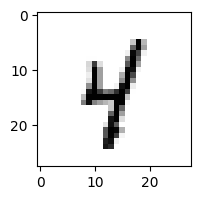

In [11]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = [2, 2] # [1,1]
plt.imshow(images[0], cmap='Greys')
print('image label = ',labels[0])

## Exercício 3

a) Faça o 'reshape' do array das imagens para que cada imagem passe a ser representada por um vetor em vez de uma matriz.

b) Mude a representação dos labels das imagens para 'one-hot encoding'

#### Fazer reshape do array das imagens para que cada imagem corresponda a um vetor (as linhas todas coladas) ###

In [12]:
images = np.reshape(images,(60000,28*28))
images.shape

(60000, 784)

#### converter o label de cada imagem num vetor de tamanho 10 ('one-hot encoding') ### 

In [13]:
n = labels.shape[0]
hot1labels = np.zeros((n, 10))
for i in range(n):
    hot1labels[i,labels[i]] = 1.0

In [14]:
for i in range(5):
    print(labels[i], ' ->', hot1labels[i])

4  -> [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
1  -> [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
0  -> [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
7  -> [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
8  -> [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


#### Testar ffwd

In [15]:
m,n = images.shape
print(m,n)
jj, k = hot1labels.shape
assert jj == m
nhid = 200
W10 = 1.0E-4*np.random.randn(n+1, nhid)
W20 = 1.0E-4*np.random.randn(nhid+1, k)

60000 784


In [16]:
o,u2, z, u1 = ffwd(images, W10,W20)

In [17]:
# testar grad
dw1,dw2 = grad(images, W10, W20, hot1labels) 
print(dw1.shape)
print(dw2.shape)

(785, 200)
(201, 10)


In [18]:
# testar iter
nw1,nw2 = iter(images, W10, W20, hot1labels, 1E-11) 

## Exercício 4 ##
Decomponha o conjunto, MNIST DATASET (train), em subconjuntos de 100 imagens de modo a serem utilizados para treinar uma rede nestas imagens usando a ***Descida do Gradiente Estocástica***. Tenha em conta que terá de fazer aos 'labels' um processamento correspondente ao que fez para as imagens.

In [19]:
imagesXX = np.reshape(images, (600,100,784))#/255
hot1labelsXX = np.reshape(hot1labels,(600,100,10))

In [20]:
def catEnt(P,Y):
    m,k  = Y.shape
    assert P.shape == (m,k)
    P = np.maximum(P, 1.0e-9) # para evitar overflow
    return np.mean(np.sum(-Y*np.log(P),axis=1))

In [21]:
def catAccu(P,Y):
    m,k  = Y.shape
    assert P.shape == (m,k)
    return np.sum(np.argmax(P,axis=1)==np.argmax(Y,axis=1))/m

In [22]:
probs = np.array([[0.3,0.7], [0.8,0.2]])
labs = np.array([[1,0], [1,0]])
catAccu(labs,probs)

np.float64(0.5)

## Exercício 5

Crie uma função que dados


- Uma decomposição do conjunto de treino $X$ num familia de subconjuntos $(X)_i$, e a correspondente 
decomposição dos labels, $(Y_i)$
 
- Matrizes $W_1$ e $W_2$ (pesos para a única camada oculta e camada de saída de uma rede neuronal), com dimensões adequadas

- Um número real $l$, coeficiente de aprendizagem

efetue uma época na descida estocástica do gradiente, usando cada um dos $(X)_i$ como 'batch', e
tenha como saída,  novas matrizes, $W_1$ e $W_2$, o valor médio da Entropia cruzada  e o valor médio da 'accuracy', ao longo das iterações . Utilize a função definida no exercício 2 em cada iteração, em vez de repetir o código aí criado e use as funções criadas nos exercícios da regressão logística para calcular a entropia cruzada e a 'accuracy' em cada iteração. 

In [23]:
def epoch(XX, W1, W2, l,YY):
    nW1 = W1.copy()
    nW2 = W2.copy()
    nb = XX.shape[0]
    accus = np.zeros(nb)
    losses = np.zeros(nb)
    for i, data in enumerate(XX):
        nW1, nW2 = iter(data, nW1,nW2,YY[i],l)
        O, _, _, _ = ffwd(data, nW1, nW2)
        losses[i] =catEnt(O,YY[i]) 
        accus[i] = catAccu(O,YY[i])
    return nW1, nW2, np.mean(accus), np.mean(losses)

In [24]:
# testar epoch
nW1, nW2,accus,losses =epoch(imagesXX, W10, W20, 1E-5,hot1labelsXX)
print(accus,losses)

0.34191666666666665 2.3021432748637767


### Exercício 6

Escolha um valor apropriado para o número de unidades na camada oculta, inicialize matrizes $W_1$ e $W_2$ e vá escolhendo uma valor adequado para $l$ na função do exercício 5, com o objetivo de,  efectuando o número de épocas necessárias, obter, no conjunto de treino do MNIST, criado no exercício 4, uma precisão de 99%.

In [25]:

nW1 = W10.copy()
nW2 = W20.copy()
l = 2E-4
for i in range(50):
    nW1, nW2,accus,losses =epoch(imagesXX, nW1, nW2, l,hot1labelsXX)
    print(i,accus,losses)

0 0.6530666666666667 1.2181230676451242
1 0.8963166666666667 0.37477536821862706
2 0.9159666666666666 0.301292874636789
3 0.92665 0.2628314498429369
4 0.9354 0.23277258940562887
5 0.94275 0.20803159068724844
6 0.9483333333333334 0.18793350857960386
7 0.9530166666666666 0.17134702515729408
8 0.9573000000000002 0.1572860419084588
9 0.9607166666666668 0.14513780225574374
10 0.9640833333333334 0.13454753465316502
11 0.9670500000000001 0.12525257550028834
12 0.96925 0.11698675847195995
13 0.9712666666666666 0.10960395530657069
14 0.9732166666666666 0.10305162110715402
15 0.9749500000000001 0.09714549856768663
16 0.9763 0.09180603063190441
17 0.97775 0.0869504975079194
18 0.9794499999999999 0.08249067154513959
19 0.9805499999999999 0.07842619871003931
20 0.9816333333333334 0.07469147409446786
21 0.9825666666666666 0.0712210612958502
22 0.9835 0.06800905805856301
23 0.9841333333333334 0.06503532920627343
24 0.9848500000000001 0.062251903658995085
25 0.9856333333333334 0.05966698626818258
26 0

## Exercício 7

Crie uma rede com 2 camadas ocultas para o mesmo dataset (MNIST) e treine-a com a descida estocástica do  gradiente.


In [26]:
def ffwd2hid(X, W1, W2, W3):
    assert X.ndim == 2
    m = X.shape[0]
    XX = np.concatenate([X, np.ones((m,1))], axis=1)
    U1 = np.matmul(XX, W1)
    Z1 = Relu(U1)
    ZZ1 = np.concatenate([Z1, np.ones((m,1))], axis=1)
    U2 = np.matmul(ZZ1, W2)
    Z2 = Relu(U2)
    ZZ2 = np.concatenate([Z2, np.ones((m,1))], axis=1)
    U3 = np.matmul(ZZ2, W3)
    O = softmax(U3)
    assert not np.any(np.isnan(O))
    return O, U3, Z2, U2, Z1, U1
    

In [27]:
# função auxiliar
def grad2hid(X, W1, W2, W3, Y):
    m = X.shape[0]
    assert W1.shape[0] == X.shape[1] + 1
    assert W1.shape[1] + 1 ==  W2.shape[0]
    assert W2.shape[1] + 1 ==  W3.shape[0]
    O,U3, Z2, U2, Z1, U1 = ffwd2hid(X, W1,W2, W3)
    assert O.shape == Y.shape
    dLdU3 =  -1.0/m*(Y-O)
    ZZ2 = np.concatenate([Z2, np.ones((m,1))], axis=1)
    dLdW3 = np.matmul(ZZ2.T, dLdU3)
    dLdZZ2 = np.matmul(dLdU3, W3.T)
    # assert (dLdZZ.shape[0] == Z.shape[0] and  dLdZZ.shape[1] == Z.shape[1] +1)
    dLdZ2 = dLdZZ2[:,:-1]
    dLdU2 = dLdZ2 * (U2>0)
    ZZ1 = np.concatenate([Z1, np.ones((m,1))], axis=1)
    dLdW2 = np.matmul(ZZ1.T, dLdU2)
    dLdZZ1 = np.matmul(dLdU2, W2.T)
    dLdZ1 = dLdZZ1[:,:-1]
    dLdU1 = dLdZ1 * (U1>0)
    XX = np.concatenate([X, np.ones((m,1))], axis=1)
    dLdW1 = np.matmul(XX.T, dLdU1)
    return dLdW1, dLdW2, dLdW3
    #assert dLdW2.shape == W2.shape
    # assert not np.any(np.isnan(dLdW1))
    # assert dLdW1.shape == W1.shape

In [28]:
def iter2hid(X, W1, W2, W3,Y, l):
    dLdW1, dLdW2, dLdW3 =  grad2hid(X, W1, W2, W3, Y)
    newW1 = W1-l*dLdW1
    newW2 = W2-l*dLdW2
    newW3 = W3-l*dLdW3    
    return newW1, newW2, newW3

In [29]:
def epoch2hid(XX, W1, W2,W3,l,YY):
    
    nW1 = W1.copy()
    nW2 = W2.copy()
    nW3 = W3.copy()
    nb = XX.shape[0]
    accus = np.zeros(nb)
    losses = np.zeros(nb)
    for i, data in enumerate(XX):
        nW1, nW2, nW3 = iter2hid(data, nW1,nW2,nW3, YY[i],l)
        O, _, _, _ ,_,_= ffwd2hid(data, nW1, nW2,nW3)
        losses[i] =catEnt(O,YY[i]) 
        accus[i] = catAccu(O,YY[i])
    return nW1, nW2, nW3, np.mean(accus), np.mean(losses)

In [30]:
n = imagesXX.shape[-1]
nhid1 = 150
nhid2 = 100
k = 10
W10 = 1.0E-4*np.random.randn(n+1, nhid1)
W20 = 1.0E-4*np.random.randn(nhid1+1,nhid2 )
W30 = 1.0E-4*np.random.randn(nhid2+1, k)
nW1 = W10.copy()
nW2 = W20.copy()
nW3 = W30.copy()
l = 5E-3
for j in range(20):
    nW1, nW2,nW3, accus,losses =epoch2hid(imagesXX, nW1, nW2, nW3,l,hot1labelsXX)
    print(j,accus,losses)

0 0.11273333333333331 2.3022015026132854
1 0.11236666666666664 2.301712366010003
2 0.11236666666666664 2.3014453531973382
3 0.12258333333333332 2.2912313608622026
4 0.5170166666666667 1.2587076931463477
5 0.9430166666666667 0.21095007172679614
6 0.9795333333333334 0.09096339580666056
7 0.9889666666666669 0.056073300412114196
8 0.9927499999999999 0.03979344414553783
9 0.995 0.03011550826851445
10 0.9965333333333333 0.023285747944039082
11 0.9975666666666666 0.018363514803839555
12 0.9982333333333334 0.01457698924306655
13 0.9987 0.011752588181375378
14 0.9991000000000001 0.009380747794807638
15 0.9993000000000001 0.007621008086203968
16 0.9996166666666666 0.006159598491223251
17 0.9995833333333334 0.005139987920338625
18 0.9997166666666667 0.004336050106865468
19 0.9998500000000001 0.0036107426494930745


In [31]:
nW3.shape

(101, 10)

In [32]:
%pdb

Automatic pdb calling has been turned ON
